
## Introduction to TopoToolbox

Welcome to the TopoToolbox Gallery, a collection of user\-contributed demonstrations of TopoToolbox!


To begin, we will create a hillshade of a digital elevation model of Big Tujunga creek in California. Make sure you have installed TopoToolbox and that it is on your MATLAB path.


The Big Tujunga DEM is provided as one of the example DEMs with TopoToolbox, so we can load it using the `GRIDobj` constructor.


In [1]:
DEM = GRIDobj('srtm_bigtujunga30m_utm11.tif')

DEM = 
  GRIDobj with properties:
           Z: [643x1197 single]
    cellsize: 30
          wf: [2x3 double]
        size: [643 1197]
        name: ''
       zunit: ''
      xyunit: ''
      georef: [1x1 map.rasterref.MapCellsReference]



The DEM is returned as a `GRIDobj`, TopoToolbox's representation of single\-band raster datasets. To make a hillshade, we can use the `imageschs` method on the `GRIDobj`. Instead of using TopoToolbox's default colormap, we will produce a greyscale hillshade by giving it a single color of white to represent the lightest value. `imageschs` takes care of shading the DEM.


In [2]:
tiledlayout(1,2)
nexttile
imageschs(DEM,[], colormap=[1, 1, 1], colorbar=false)
xlabel("Easting (m)")
ylabel("Northing (m)")



Now let's add a visualization of the stream network to this map. We first create a `FLOWobj` storing flow directions on the DEM and then a `STREAMobj` that picks out the streams. We also call the `klargestconncomps` method on this `STREAMobj` to restrict our analysis to the main watershed.


In [3]:
FD = FLOWobj(DEM);
S  = STREAMobj(FD);
S = klargestconncomps(S, 1);


We can add the `STREAMobj` to our plot with its `plot` method.


In [4]:
hold on
plot(S, color='k')
hold off


Finally, let's use the `trunk` method on the `STREAMobj to pick out the longest stream in the watershed and the plotdz method to plot its profile in another subplot.`



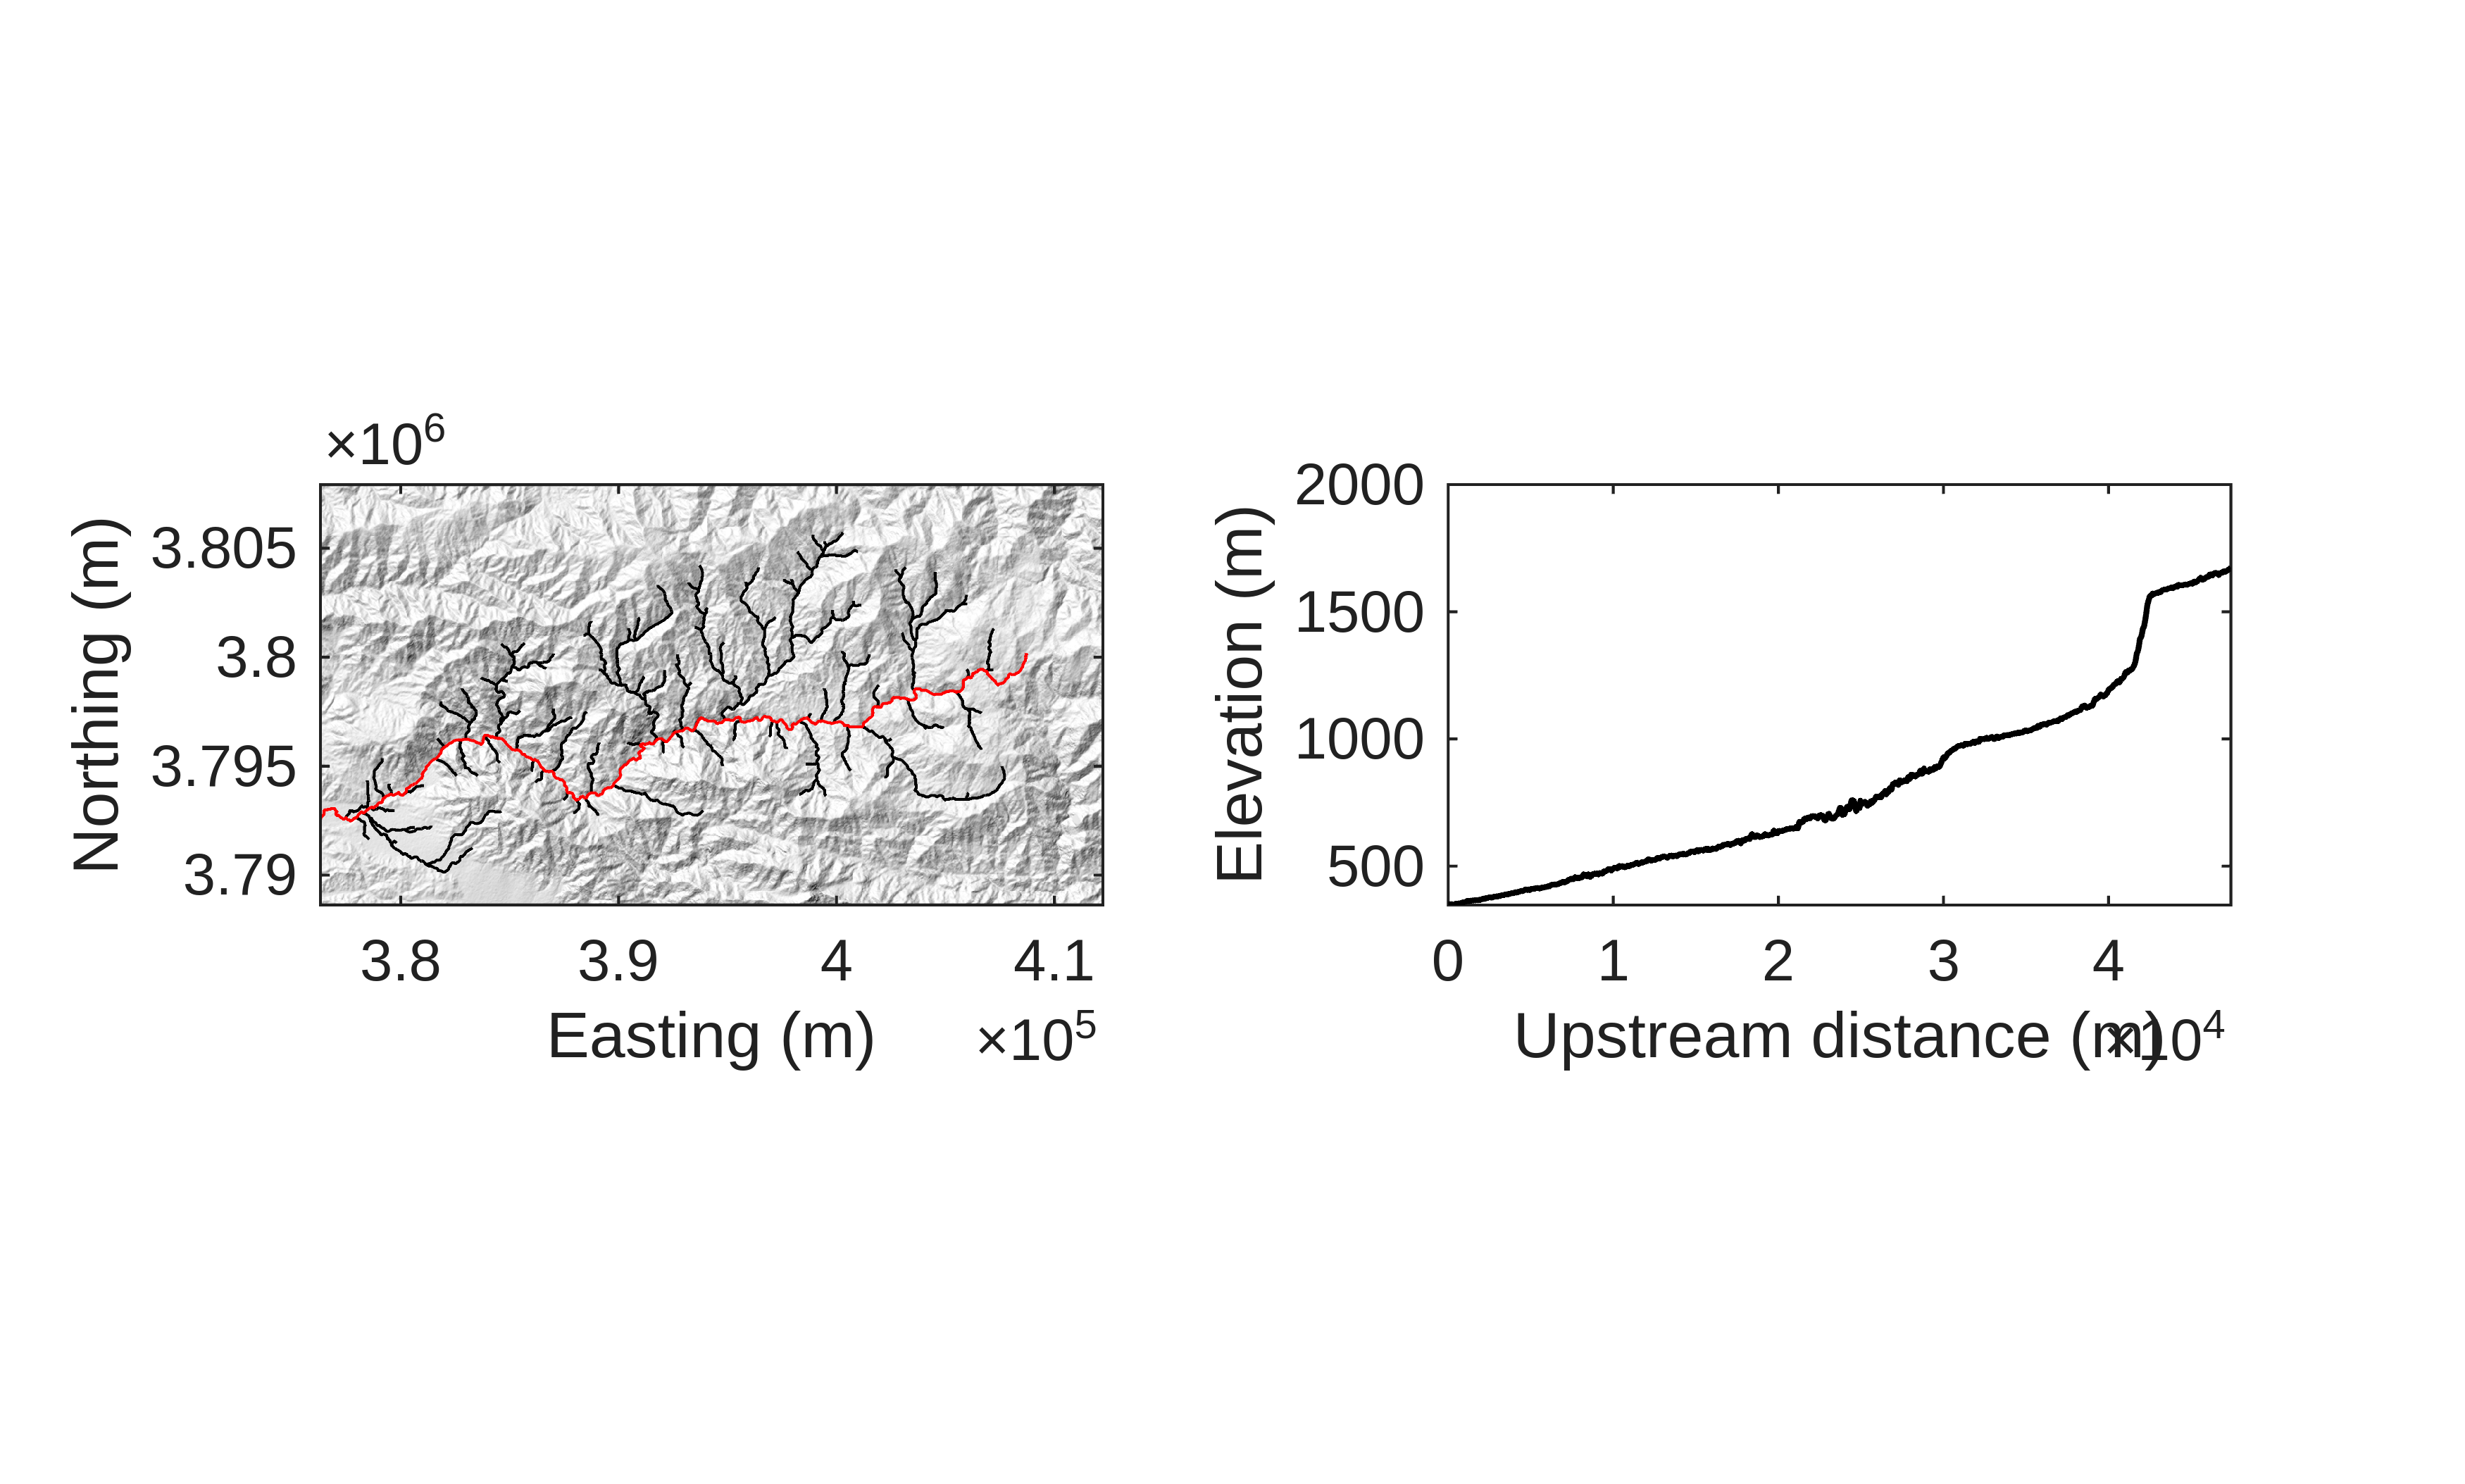

In [5]:
T = S.trunk();
hold on
plot(T, color='r')
hold off

ax2 = nexttile;
plotdz(T, DEM, color="black")
xlabel("Upstream distance (m)")
ylabel("Elevation (m)")
ax2.PlotBoxAspectRatio = [1 643/1197 1];